<a href="https://colab.research.google.com/github/MadhuryaPasan/ML_AI_DL/blob/TensorFlow/Build_an_image_classifier_(ML_Zero_to_Hero_Part_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/rps.zip \
    -O /tmp/rps.zip

!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/rps-test-set.zip \
    -O /tmp/rps-test-set.zip

--2026-06-26 12:09:06--  https://storage.googleapis.com/learning-datasets/rps.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.108.207, 142.251.121.207, 192.178.142.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.108.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 200682221 (191M) [application/zip]
Saving to: ‘/tmp/rps.zip’

/tmp/rps.zip        100%[===================>] 191.38M   203MB/s    in 0.9s    

2026-06-26 12:09:07 (203 MB/s) - ‘/tmp/rps.zip’ saved [200682221/200682221]

--2026-06-26 12:09:07--  https://storage.googleapis.com/learning-datasets/rps-test-set.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.108.207, 142.251.121.207, 192.178.142.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.108.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29516758 (28M) [application/zip]
Saving to: ‘/tmp/rps-test-set.zip’

/t

In [2]:
import os
import zipfile

local_zip = '/tmp/rps.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/')
zip_ref.close()

local_zip = '/tmp/rps-test-set.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/')
zip_ref.close()

In [3]:
rock_dir = os.path.join('/tmp/rps/rock')
paper_dir = os.path.join('/tmp/rps/paper')
scissors_dir = os.path.join('/tmp/rps/scissors')

print('total training rock images:', len(os.listdir(rock_dir)))
print('total training paper images:', len(os.listdir(paper_dir)))
print('total training scissors images:', len(os.listdir(scissors_dir)))

rock_files = os.listdir(rock_dir)
print(rock_files[:10])

paper_files = os.listdir(paper_dir)
print(paper_files[:10])

scissors_files = os.listdir(scissors_dir)
print(scissors_files[:10])

total training rock images: 840
total training paper images: 840
total training scissors images: 840
['rock02-067.png', 'rock02-007.png', 'rock07-k03-113.png', 'rock04-065.png', 'rock05ck01-019.png', 'rock05ck01-043.png', 'rock05ck01-048.png', 'rock03-026.png', 'rock04-033.png', 'rock06ck02-033.png']
['paper06-096.png', 'paper03-069.png', 'paper06-018.png', 'paper06-093.png', 'paper05-081.png', 'paper03-109.png', 'paper01-040.png', 'paper07-070.png', 'paper01-078.png', 'paper01-030.png']
['testscissors01-008.png', 'testscissors02-029.png', 'scissors02-063.png', 'testscissors01-002.png', 'testscissors01-106.png', 'scissors04-049.png', 'scissors01-037.png', 'testscissors03-064.png', 'scissors04-008.png', 'scissors01-026.png']


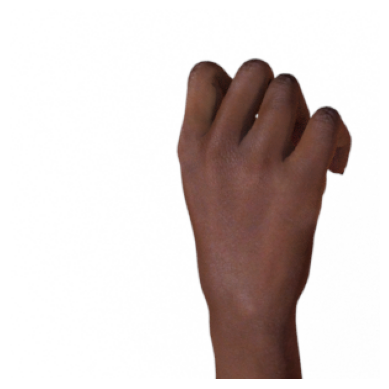

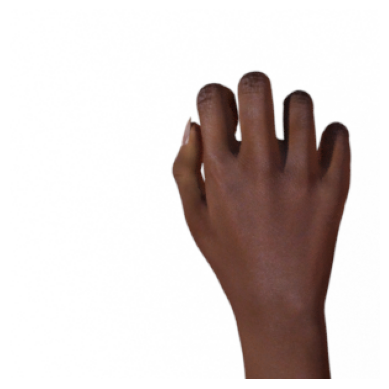

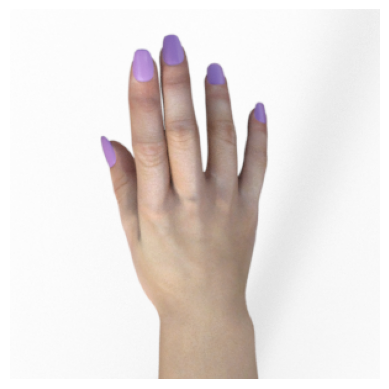

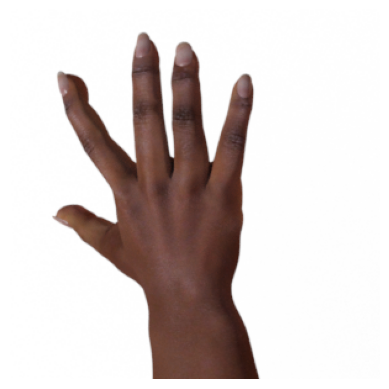

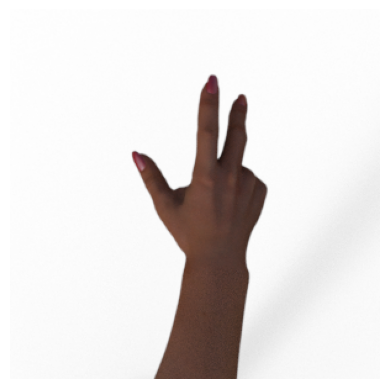

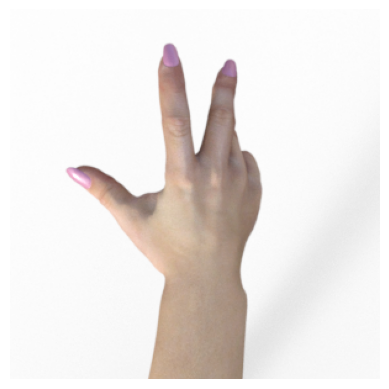

In [4]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pic_index = 2

next_rock = [os.path.join(rock_dir, fname)
                for fname in rock_files[pic_index-2:pic_index]]
next_paper = [os.path.join(paper_dir, fname)
                for fname in paper_files[pic_index-2:pic_index]]
next_scissors = [os.path.join(scissors_dir, fname)
                for fname in scissors_files[pic_index-2:pic_index]]

for i, img_path in enumerate(next_rock+next_paper+next_scissors):
  #print(img_path)
  img = mpimg.imread(img_path)
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

In [6]:
!pip install keras-preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.6 MB/s eta 0:00:00


In [7]:
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator

In [11]:
# expand dataset.
# helpfull to prevent overfitting and improve generalization

TRAINING_DIR = "/tmp/rps/"
training_datagen = ImageDataGenerator(
      rescale = 1./255, #normalization
	    rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

In [12]:
VALIDATION_DIR = "/tmp/rps-test-set/"
validation_datagen = ImageDataGenerator(rescale = 1./255) #Normalization

In [13]:
train_generator = training_datagen.flow_from_directory(
	TRAINING_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126
)

validation_generator = validation_datagen.flow_from_directory(
	VALIDATION_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126
)

Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.


In [14]:
model = tf.keras.models.Sequential(
    [
        # input shape is the size of image 150x150 with 3 bytes of color
        # 64 number of filters
        # (3,3) size of each filter
        tf.keras.layers.Conv2D(64,(3,3), activation='relu',input_shape=(150,150,3)),
        tf.keras.layers.MaxPool2D(2,2),

        tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(128,(3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(128,(3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        # Flatten the results to feed into a DNN
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.5),

        # 512 neuron hidden layers
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(3,activation='softmax')
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,473,475 (13.25 MB)

 Trainable params: 3,473,475 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss = 'categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [17]:
history = model.fit(train_generator,epochs=25, steps_per_epoch=20,validation_data=validation_generator, verbose=1,validation_steps=3)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 225s 11s/step - accuracy: 0.3298 - loss: 1.2363 - val_accuracy: 0.4624 - val_loss: 1.0913
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 191s 10s/step - accuracy: 0.3512 - loss: 1.1023 - val_accuracy: 0.6344 - val_loss: 1.0933
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 202s 9s/step - accuracy: 0.4163 - loss: 1.0913 - val_accuracy: 0.3817 - val_loss: 1.0662
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 214s 10s/step - accuracy: 0.4845 - loss: 1.0028 - val_accuracy: 0.7930 - val_loss: 0.8748
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 188s 9s/step - accuracy: 0.5421 - loss: 0.9333 - val_accuracy: 0.5753 - val_loss: 0.8760
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 205s 10s/step - accuracy: 0.6095 - loss: 0.8155 - val_accuracy: 0.9247 - val_loss: 0.6242
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 211s 10s/step - accuracy: 0.6631 - loss: 0.7105 - val_accuracy: 0.9839 - val_loss: 0.3040
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 190s 9s/step - accuracy: 0.7333 - loss: 0.5839 - val_accuracy: 0.879

In [18]:
model.save("rsp.h5")

In [19]:
model.save('my_model.keras')

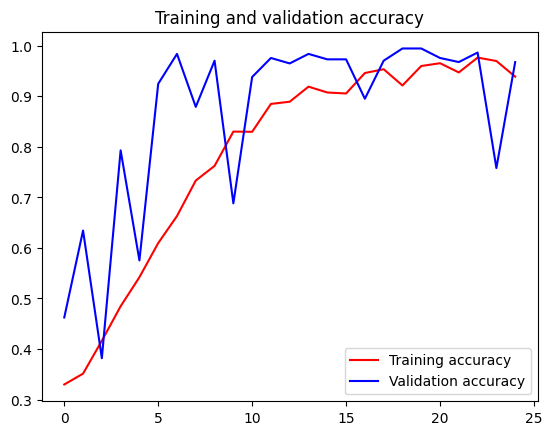

<Figure size 640x480 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()


plt.show()

In [22]:
import numpy as np
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = fn
  img = image.load_img(path, target_size=(150, 150))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)
  print(fn)
  print(classes)

Saving Screenshot 2026-06-26 at 19-22-48 rock paper scissors - Google Search.png to Screenshot 2026-06-26 at 19-22-48 rock paper scissors - Google Search.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Screenshot 2026-06-26 at 19-22-48 rock paper scissors - Google Search.png
[[1. 0. 0.]]
